In [4]:
!pip install shap

In [5]:
# Install shap if not already installed
# Run this in a separate cell first: !pip install shap

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Import shap after installation
try:
    import shap
    print("SHAP imported successfully")
except ImportError:
    print("SHAP not installed. Run: !pip install shap")
    # You can continue without shap for now if needed

df = pd.read_csv('cs-training.csv', index_col=0)
print(df.shape)
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

SHAP imported successfully
(150000, 11)
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [11]:
# Valeurs manquantes
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# Outliers connus de ce dataset (age=0, ratios aberrants à 96/98)
df = df[df['age'] > 18]
df = df[df['NumberOfTimes90DaysLate'] < 90]

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [13]:
logit = LogisticRegression(max_iter=100000, class_weight='balanced')
logit.fit(X_train, y_train)
proba_logit = logit.predict_proba(X_test)[:,1]
auc_logit = roc_auc_score(y_test, proba_logit)
print(f"AUC Logit : {auc_logit:.3f}")

AUC Logit : 0.814


In [14]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, proba_rf)
print(f"AUC Random Forest : {auc_rf:.3f}") 

AUC Random Forest : 0.854


In [19]:
from sklearn.metrics import roc_curve

# Gini = 2*AUC - 1
gini_logit = 2 * auc_logit - 1
gini_rf = 2 * auc_rf - 1

print(f"Gini Logit : {gini_logit:.3f}")
print(f"Gini Random Forest : {gini_rf:.3f}")

# KS statistic (Kolmogorov-Smirnov)
def ks_statistic(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    ks = max(tpr - fpr)
    return ks

ks_logit = ks_statistic(y_test, proba_logit)
ks_rf = ks_statistic(y_test, proba_rf)

print(f"KS Logit : {ks_logit:.3f}")
print(f"KS Random Forest : {ks_rf:.3f}")

Gini Logit : 0.627
Gini Random Forest : 0.708
KS Logit : 0.495
KS Random Forest : 0.552


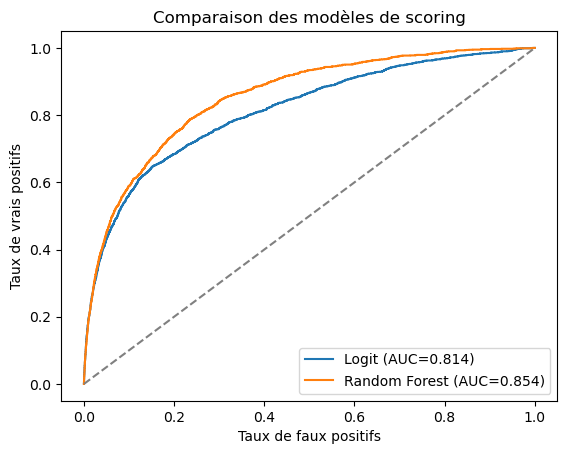

In [15]:
fpr_l, tpr_l, _ = roc_curve(y_test, proba_logit)
fpr_r, tpr_r, _ = roc_curve(y_test, proba_rf)

plt.plot(fpr_l, tpr_l, label=f'Logit (AUC={auc_logit:.3f})')
plt.plot(fpr_r, tpr_r, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.legend()
plt.title('Comparaison des modèles de scoring')
plt.savefig('roc_comparison.png')

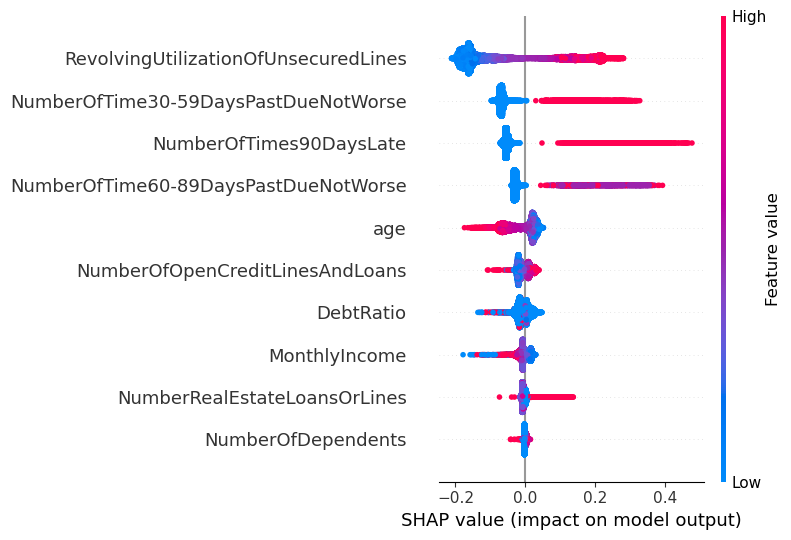

In [18]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Sélectionner explicitement la classe positive (défaut = 1)
if isinstance(shap_values, list):
    shap_vals_classe1 = shap_values[1]
elif shap_values.ndim == 3:
    shap_vals_classe1 = shap_values[:, :, 1]
else:
    shap_vals_classe1 = shap_values

shap.summary_plot(shap_vals_classe1, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')